In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
# Tratamiento de Datos
import pandas as pd
import numpy as np
from IPython.display import display

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Para que se muestren todas las columnas al inspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

In [3]:
from framework import sp_carga_exploracion as sc
from framework import sp_limpieza_transformacion as sl
from framework import sp_eda as se
from framework import sp_abtest as sb
from framework import sp_modelado as sm

#### CARGA DE ARCHIVOS PKL

In [7]:
import joblib

datos = joblib.load('../data/processed/datos_preprocesados.pkl')

X_train_clf = datos['X_train_clf']
X_test_clf = datos['X_test_clf']
y_train_clf = datos['y_train_clf']
y_test_clf = datos['y_test_clf']

#### LogisticRegression

Antes de entrenar, la diferencia clave respecto a la regresión: aquí no predices un número, predices una categoría (0=suspenso, 1=aprobado) — y recuerda el aviso importante que llevamos arrastrando desde el preprocesamiento: aprobado está desbalanceado (90%/10%), así que hay que leer las métricas con más cuidado que en regresión.

##### Paso 1: crear y entrenar el modelo

A diferencia de entrenar_evaluar_regresion(), esta función también te va a imprimir la matriz de confusión y el classification report completo por consola (además de devolverte el diccionario con Accuracy/Precision/Recall/F1) — mucha más información de golpe.

Antes de que lo ejecutes, cómo leer la matriz de confusión cuando la veas

Va a ser una tabla 2x2:

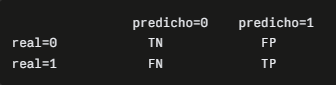

Con solo ~20 casos reales de 0 (suspenso) en el test (recuerda el 10% de 200), presta especial atención a cuántos de esos 20 el modelo consigue identificar bien — es el número que más importa aquí, no el Accuracy global (que con e

In [8]:
from sklearn.linear_model import LogisticRegression

modelo_clf = LogisticRegression()

resultados_clf = sm.entrenar_evaluar_clasificacion(modelo_clf, X_train_clf, X_test_clf, y_train_clf, y_test_clf)
print(resultados_clf)


Matriz de confusión:
[[  3  17]
 [  2 178]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.15      0.24        20
           1       0.91      0.99      0.95       180

    accuracy                           0.91       200
   macro avg       0.76      0.57      0.59       200
weighted avg       0.88      0.91      0.88       200

{'Accuracy': 0.905, 'Precision': 0.8815384615384615, 'Recall': 0.905, 'F1': 0.8784000000000001}


Justo lo que anticipaba con el aviso del desbalanceo — vamos a leerlo con calma, porque el Accuracy de 0,905 esconde un problema real que hay que sacar a la luz.

Empezamos por la matriz de confusión, la parte más honesta del resultado

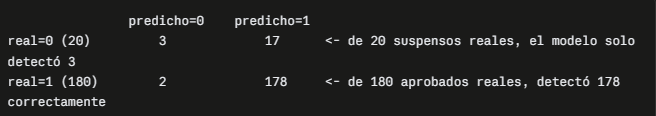

La clase minoritaria (suspenso) está fallando muchísimo

Fíjate en la fila de 0 del classification report:

0 (suspenso):  precision=0.60  recall=0.15  f1=0.24

Recall=0,15 es el número que de verdad importa aquí: de los 20 estudiantes que realmente suspendieron, el modelo solo identificó correctamente a 3 — falló en 17 de 20. El modelo está prediciendo "aprobado" casi siempre, y acierta mucho porque el 90% de los casos reales son "aprobado" — no porque entienda bien qué diferencia a quien suspende.

Por qué el Accuracy (0,905) engaña aquí

Es exactamente el aviso que te di antes de ejecutarlo: un modelo que dijera "todos aprueban" sin mirar ningún dato, ya acertaría el 90% (accuracy=0,90) sin haber aprendido nada. Tu modelo real (0,905) apenas mejora esa base ingenua — la mejora real está solo en esos 3 suspensos que sí detecta.

¿Por qué falla tanto en la clase minoritaria?

Con solo 102 casos de suspenso en todo el dataset (de 1000), y encima repartidos 90/10 en train/test, el modelo tiene muy pocos ejemplos de "cómo es un suspenso" para aprender el patrón — tiende a "refugiarse" en predecir la clase mayoritaria, porque estadísticamente le sale más a cuenta en promedio.

Qué hacer al respecto — no es un fallo tuyo, es un problema conocido con datos desbalanceados

Hay dos vías típicas, que podemos explorar cuando quieras (no hace falta ahora mismo):

1. class_weight='balanced' en LogisticRegression() — le dice al modelo que penalice más los errores en la clase minoritaria, sin tener que tocar los datos.
2. Sobremuestreo/submuestreo (SMOTE, etc.) — técnicas más avanzadas para equilibrar las clases antes de entrenar.

**Modelo de clasificación — LogisticRegression (resultado inicial)**

Accuracy=0.905, pero esta cifra es engañosa dado el desbalanceo
(90%/10%): el modelo solo identifica correctamente 3 de 20 suspensos
reales (recall=0.15 para la clase minoritaria). Predice "aprobado"
de forma casi sistemática, beneficiándose del desbalanceo en el
accuracy sin haber aprendido a distinguir bien el patrón de
suspenso.

Próximo paso: reentrenar con class_weight='balanced' para forzar al
modelo a prestar más atención a la clase minoritaria.

**`class_weight='balanced'` para ver si mejora**

Antes de que lo ejecutes, qué esperar con este cambio: class_weight='balanced' hace que el modelo trate los errores en la clase minoritaria (suspenso) como "más caros" durante el entrenamiento — en la práctica, esto suele significar que el recall de la clase 0 sube (detecta más suspensos reales), pero normalmente a cambio de que la precision de la clase 0 baje (también empieza a marcar como "suspenso" a algunos que en realidad aprobaron) y que el Accuracy global baje un poco (porque ya no se refugia tanto en la clase mayoritaria). Es un trade-off, no una mejora gratis en todo a la vez.

In [9]:
modelo_clf_balanceado = LogisticRegression(class_weight='balanced')

resultados_clf_bal = sm.entrenar_evaluar_clasificacion(modelo_clf_balanceado, X_train_clf, X_test_clf, y_train_clf, y_test_clf)
print(resultados_clf_bal)


Matriz de confusión:
[[ 13   7]
 [ 53 127]]

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.65      0.30        20
           1       0.95      0.71      0.81       180

    accuracy                           0.70       200
   macro avg       0.57      0.68      0.56       200
weighted avg       0.87      0.70      0.76       200

{'Accuracy': 0.7, 'Precision': 0.8726820443238352, 'Recall': 0.7, 'F1': 0.7582580358465413}


Justo el trade-off que anticipaba, y con mucha intensidad — vamos a leerlo bien, porque aquí hay una decisión de negocio real que tomar, no solo un número "mejor" o "peor".

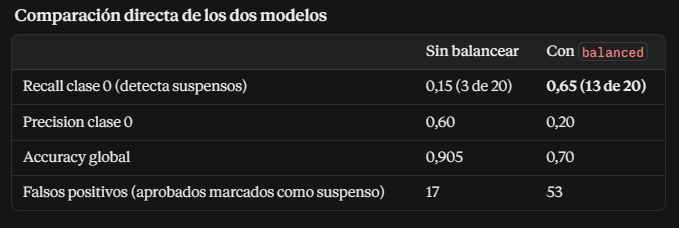

La mejora real, y su coste

Mejora clara: pasas de detectar 3 de 20 suspensos a detectar 13 de 20 — más del cuádruple. Si el objetivo de negocio es "identificar quién necesita ayuda antes de que suspenda", este modelo es muchísimo más útil.

El coste: la precisión de la clase 0 se desploma a 0,20 — de cada 10 estudiantes que el modelo marca como "en riesgo de suspenso", solo 2 realmente lo están; los otros 8 en realidad iban a aprobar. Y el Accuracy global cae del 90,5% al 70%.

¿Cuál es "mejor"? Depende de qué error te sale más caro

Esto no tiene una respuesta puramente estadística — depende del contexto de uso:

Si el modelo se usa para "avisar/apoyar" a estudiantes en riesgo (ej. ofrecerles tutorías extra), el coste de un falso positivo es bajo (le ofreces ayuda a alguien que no la necesitaba, no pasa nada grave) — aquí el modelo balanced es claramente mejor, porque priorizas no dejar a nadie sin detectar.
Si el modelo se usa para decisiones más "duras" (ej. denegar algo, marcar como "en riesgo" de forma pública), un falso positivo tiene coste real — ahí el trade-off es más discutible.

Dado que es un dataset de estudiantes, el caso de uso más natural es el primero (identificar quién necesita apoyo), así que yo me quedaría con el modelo balanced como el más útil, aunque su Accuracy "se vea peor" en el número global.

**Modelo de clasificación — comparación con class_weight='balanced'**

| Métrica | Sin balancear | Balanceado |
|---|---|---|
| Recall suspensos | 0,15 | 0,65 |
| Precision suspensos | 0,60 | 0,20 |
| Accuracy | 0,905 | 0,70 |

Se prioriza el modelo balanceado como resultado final: en un contexto
de identificación temprana de estudiantes en riesgo, el coste de un
falso positivo (ofrecer apoyo a quien no lo necesita) es bajo,
mientras que el de un falso negativo (no detectar a quien va a
suspender) es alto. El Accuracy global, aunque más bajo, es una
métrica engañosa en un dataset desbalanceado (90%/10%) y no refleja
la utilidad real del modelo para este objetivo.